# CoastWatch HTTPS NetCDF → VirtualiZarr → local Icechunk

Small proof-of-concept based on the NDVI append notebook, but using NOAA CoastWatch North Atlantic Ocean Heat Content NetCDF files served over HTTPS. Writes a local icechunk.

## What this demo does

1. Tests that CoastWatch honors HTTP byte-range requests.
2. Opens one CoastWatch NetCDF as a VirtualiZarr dataset without downloading the science arrays.
3. Creates a **local Icechunk repository** whose chunks point back to byte ranges in the CoastWatch HTTPS NetCDF files.
4. Appends three consecutive daily files along `time`.
5. Reopens the local Icechunk repo with xarray and loads/plots `ohc`.

The CoastWatch source variables are stored contiguously in each daily NetCDF, so each daily 2-D science field will effectively behave like one relatively large virtual chunk. This demo tests whether the archive can be virtualized cleanly; it does **not** change the source chunking.

In [1]:
# Dependencies. In the git repo: pip install -r requirements.txt
# Standalone (downloaded on its own), uncomment:
# !pip install -q "icechunk>=2.1" "virtualizarr>=2.4" xarray zarr obspec-utils obstore \
#     h5netcdf h5py kerchunk scipy aiohttp requests
#
# icechunk 2.x requires Python >= 3.12. kerchunk, scipy and aiohttp are easy to miss:
# NetCDF3Parser reaches kerchunk.netCDF3.NetCDF3ToZarr, which subclasses scipy's
# netcdf_file, and kerchunk reads the headers through fsspec's async HTTPFileSystem.
# This notebook writes locally and needs no cloud credentials.

In [2]:
import shutil
import time
from pathlib import Path

import requests
import xarray as xr
import icechunk

from obstore.store import HTTPStore
from obspec_utils.registry import ObjectStoreRegistry
from virtualizarr import open_virtual_dataset
from virtualizarr.parsers import HDFParser

## CoastWatch URLs

This uses three consecutive 2026 day-of-year files around the example file `ohc_na14QG3_2026_230.nc`.

If one of these files is not present on the server, just change `doys` to three known available days.

In [3]:
year = 2026
base = f"https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na14/{year}"

doys = [228, 229, 230]
urls = [f"{base}/ohc_na14QG3_{year}_{doy:03d}.nc" for doy in doys]

urls

['https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na14/2026/ohc_na14QG3_2026_228.nc',
 'https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na14/2026/ohc_na14QG3_2026_229.nc',
 'https://coastwatch.noaa.gov/pub/socd2/coastwatch/ocean_heat/na14/2026/ohc_na14QG3_2026_230.nc']

## 1. Confirm HTTP byte-range access

CoastWatch returned `403` to the default `python-requests` User-Agent in an earlier test, but accepted browser-like and Icechunk User-Agents. This explicitly asks for only the first 100 bytes.

In [4]:
BROWSER_UA = (
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
    "AppleWebKit/537.36 (KHTML, like Gecko) "
    "Chrome/150.0.0.0 Safari/537.36"
)

r = requests.get(
    urls[-1],
    headers={
        "User-Agent": BROWSER_UA,
        "Range": "bytes=0-99",
    },
)

print("status:", r.status_code)
print("content-range:", r.headers.get("Content-Range"))
print("accept-ranges:", r.headers.get("Accept-Ranges"))
print("bytes returned:", len(r.content))

assert r.status_code == 206, "Server did not honor the byte-range request"
assert len(r.content) == 100

status: 206
content-range: bytes 0-99/3243916
accept-ranges: bytes
bytes returned: 100


In [5]:
# Icechunk 2.x sends its own User-Agent for HTTP reads.
print("Icechunk User-Agent:", icechunk.user_agent())

Icechunk User-Agent: icechunk-rust-2.2.2


## 2. Set up the HTTPS object store for VirtualiZarr

VirtualiZarr needs to read the HDF5/NetCDF metadata and identify the byte ranges that contain each array. `HTTPStore` gives it random-access HTTP reads.

We explicitly give the obstore HTTP client a browser-like User-Agent because CoastWatch rejects the default `python-requests` User-Agent. This setting is for the **VirtualiZarr metadata-reading step**.

In [6]:
http_store = HTTPStore(
    base,
    client_options={"user_agent": BROWSER_UA},
)

registry = ObjectStoreRegistry({base: http_store})
parser = HDFParser()

## 3. Open one file virtually

Load only the small coordinate variables into memory. Keep the science variables such as `ohc`, `sst`, and `ssha` virtual.

In [7]:
vds = open_virtual_dataset(
    url=urls[0],
    parser=parser,
    registry=registry,
    loadable_variables=["time", "latitude", "longitude"],
    decode_times=True,
)

vds

<xarray.Dataset> Size: 3MB
Dimensions:       (latitude: 241, longitude: 401, time: 1)
Coordinates:
  * latitude      (latitude) float32 964B 0.0 0.25 0.5 0.75 ... 59.5 59.75 60.0
  * longitude     (longitude) float32 2kB -100.0 -99.75 -99.5 ... -0.5 -0.25 0.0
  * time          (time) datetime64[ns] 8B 2026-08-17T09:23:12
Data variables:
    crs           int32 4B ManifestArray<shape=(), dtype=int32, chunks=()>
    landmask      (time, latitude, longitude) int8 97kB ManifestArray<shape=(...
    sst           (time, latitude, longitude) float32 387kB ManifestArray<sha...
    ssha          (time, latitude, longitude) float32 387kB ManifestArray<sha...
    sshaE         (time, latitude, longitude) float32 387kB ManifestArray<sha...
    iso20C        (time, latitude, longitude) float32 387kB ManifestArray<sha...
    iso26C        (time, latitude, longitude) float32 387kB ManifestArray<sha...
    omld          (time, latitude, longitude) float32 387kB ManifestArray<sha...
    ohc           (time, latitude, longitude) float32 387kB ManifestArray<sha...
    quality_flag  (time, latitude, longitude) int32 387kB ManifestArray<shape...
Attributes: (12/62)
    Metadata_Conventions:                    Unidata Dataset Discovery v1.0
    source_data:                             SMARTS Climatology+Altimeter SHA...
    sourceUrl:                               http://www.ospo.noaa.gov/Product...
    spatial_resolution:                      0.25 degree
    standard_name_vocabulary:                CF Standard Name Table v32
    time_coverage_start:                     2026-08-03T00:00:00Z
    ...                                      ...
    bounding_box_iso26C_average:             97.577734375
    bounding_box_iso26C_variance:            13.28812553171767
    bounding_box_iso26C_standard_deviation:  3.645288127393728
    bounding_box_ohc_average:                124.781884765625
    bounding_box_ohc_variance:               89.76439673423953
    bounding_box_ohc_standard_deviation:     9.47440746085155

In [8]:
# The CoastWatch science arrays should remain virtual.
# chunksizes=None in the original NetCDF means the HDF5 arrays are contiguous;
# VirtualiZarr can still represent each contiguous array as a virtual byte range.
for name, var in vds.data_vars.items():
    print(name, var.dims, var.shape, type(var.data).__name__)

crs () () ManifestArray
landmask ('time', 'latitude', 'longitude') (1, 241, 401) ManifestArray
sst ('time', 'latitude', 'longitude') (1, 241, 401) ManifestArray
ssha ('time', 'latitude', 'longitude') (1, 241, 401) ManifestArray
sshaE ('time', 'latitude', 'longitude') (1, 241, 401) ManifestArray
iso20C ('time', 'latitude', 'longitude') (1, 241, 401) ManifestArray
iso26C ('time', 'latitude', 'longitude') (1, 241, 401) ManifestArray
omld ('time', 'latitude', 'longitude') (1, 241, 401) ManifestArray
ohc ('time', 'latitude', 'longitude') (1, 241, 401) ManifestArray
quality_flag ('time', 'latitude', 'longitude') (1, 241, 401) ManifestArray


## 4. Create a local Icechunk repo with an HTTPS virtual chunk container

The Icechunk repository itself is local. The large array bytes remain in the original CoastWatch NetCDF files and are read over HTTPS only when requested.

The virtual chunk container tells Icechunk that references beginning with the CoastWatch URL prefix should be resolved using its HTTP object-store backend.

In [9]:
repo_path = Path("coastwatch-ohc-http-icechunk-demo")

if repo_path.exists():
    shutil.rmtree(repo_path)
    print(f"Cleared existing repo at {repo_path}/")

http_prefix = base + "/"

config = icechunk.RepositoryConfig.default()
config.set_virtual_chunk_container(
    icechunk.VirtualChunkContainer(
        url_prefix=http_prefix,
        store=icechunk.http_store(),
    )
)

# HTTP is public/no-auth, but Icechunk requires us to explicitly authorize
# access to virtual chunks outside the Icechunk repository.
credentials = icechunk.containers_credentials({
    http_prefix: icechunk.credentials.HttpAccess
})

storage = icechunk.local_filesystem_storage(str(repo_path))
repo = icechunk.Repository.create(
    storage,
    config,
    authorize_virtual_chunk_access=credentials,
)

session = repo.writable_session("main")

  2026-09-17T22:13:45.260602Z  WARN icechunk_arrow_object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk-arrow-object-store/src/lib.rs:330

  2026-09-17T22:13:45.270627Z  WARN icechunk_storage::readback: conditional PUT is enabled but `unsafe_use_metadata` is disabled — lost-response recovery for conditional writes requires user metadata to stamp write-ids; without it, transient PUT failures may surface as spurious conflicts even when the write actually landed. See icechunk_storage::Settings::unsafe_use_metadata.
    at icechunk-storage/src/readback.rs:31



## 5. Virtualize and append three daily files

`crs` and `quality_information` are scalar metadata variables rather than time-varying fields. Dropping them keeps the append example simple. The remaining variables, including `ohc`, are appended along `time`.

In [10]:
for i, url in enumerate(urls):
    start = time.perf_counter()
    print(f"Adding {Path(url).name}")

    vds_day = open_virtual_dataset(
        url=url,
        parser=parser,
        registry=registry,
        loadable_variables=["time", "latitude", "longitude"],
        decode_times=True,
    ).drop_vars(
        ["crs", "quality_information"],
        errors="ignore",
    )

    if i == 0:
        vds_day.vz.to_icechunk(session.store)
    else:
        vds_day.vz.to_icechunk(
            session.store,
            append_dim="time",
        )

    print(f"  finished in {time.perf_counter() - start:.2f} s")

snapshot_id = session.commit(f"Add {len(urls)} CoastWatch OHC days")
print("Committed:", snapshot_id)

Adding ohc_na14QG3_2026_228.nc


  finished in 0.93 s
Adding ohc_na14QG3_2026_229.nc


  finished in 0.99 s
Adding ohc_na14QG3_2026_230.nc


  finished in 0.98 s
Committed: KBRYM5P76YSHS48MP9AG


## 6. Reopen the local Icechunk repo

The repository metadata are local, but reading a virtual science chunk follows its byte-range reference back to CoastWatch HTTPS.

In [11]:
repo2 = icechunk.Repository.open(
    storage,
    config,
    authorize_virtual_chunk_access=credentials,
)

session2 = repo2.readonly_session("main")

ds = xr.open_zarr(
    session2.store,
    consolidated=False,
    chunks=None,
)

ds

<xarray.Dataset> Size: 11MB
Dimensions:       (time: 3, latitude: 241, longitude: 401)
Coordinates:
  * time          (time) datetime64[ns] 24B 2026-08-17T09:23:12 ... 2026-08-1...
  * latitude      (latitude) float32 964B 0.0 0.25 0.5 0.75 ... 59.5 59.75 60.0
  * longitude     (longitude) float32 2kB -100.0 -99.75 -99.5 ... -0.5 -0.25 0.0
Data variables:
    sshaE         (time, latitude, longitude) float32 1MB ...
    iso26C        (time, latitude, longitude) float32 1MB ...
    ohc           (time, latitude, longitude) float32 1MB ...
    omld          (time, latitude, longitude) float32 1MB ...
    iso20C        (time, latitude, longitude) float32 1MB ...
    quality_flag  (time, latitude, longitude) float64 2MB ...
    sst           (time, latitude, longitude) float32 1MB ...
    ssha          (time, latitude, longitude) float32 1MB ...
    landmask      (time, latitude, longitude) int8 290kB ...
Attributes: (12/62)
    Metadata_Conventions:                    Unidata Dataset Discovery v1.0
    source_data:                             SMARTS Climatology+Altimeter SHA...
    sourceUrl:                               http://www.ospo.noaa.gov/Product...
    spatial_resolution:                      0.25 degree
    standard_name_vocabulary:                CF Standard Name Table v32
    time_coverage_start:                     2026-08-05T00:00:00Z
    ...                                      ...
    bounding_box_iso26C_average:             101.121484375
    bounding_box_iso26C_variance:            38.16844652308897
    bounding_box_iso26C_standard_deviation:  6.1780617124700985
    bounding_box_ohc_average:                123.471328125
    bounding_box_ohc_variance:               61.254501920653226
    bounding_box_ohc_standard_deviation:     7.826525533124723

## 7. Check the time axis and load one OHC field

This is the important end-to-end test: xarray reads the Icechunk metadata, Icechunk resolves the virtual reference, and the array bytes come from the original CoastWatch NetCDF over an HTTP range request.

> **If this raises `StorageError: error fetching virtual reference ... connection closed before message completed`, just run the cell again.** CoastWatch's HTTPS endpoint is slow and intermittently drops connections; the write path above retries around it, but a chunk read has no retry and surfaces the drop as a storage error. It looks like a corrupt reference and is not one — a read that fails this way succeeds on a retry with no changes.

In [12]:
print(ds.time.values)

start = time.perf_counter()
ohc0 = ds["ohc"].isel(time=0).load()
print(f"Loaded one OHC field in {time.perf_counter() - start:.2f} s")
print(ohc0)

['2026-08-17T09:23:12.000000000' '2026-08-18T11:31:12.000000000'
 '2026-08-19T11:31:12.000000000']


Loaded one OHC field in 0.65 s
<xarray.DataArray 'ohc' (latitude: 241, longitude: 401)> Size: 387kB
array([[nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       ...,
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.],
       [nan, nan, nan, ...,  0.,  0.,  0.]],
      shape=(241, 401), dtype=float32)
Coordinates:
  * latitude   (latitude) float32 964B 0.0 0.25 0.5 0.75 ... 59.5 59.75 60.0
  * longitude  (longitude) float32 2kB -100.0 -99.75 -99.5 ... -0.5 -0.25 0.0
    time       datetime64[ns] 8B 2026-08-17T09:23:12
Attributes:
    units:          kJ cm^-2
    long_name:      ocean heat content
    standard_name:  integral_of_sea_water_potential_temperature_wrt_depth_exp...
    grid_mapping:   crs
    valid_min:      0.0


## 8. Plot one day

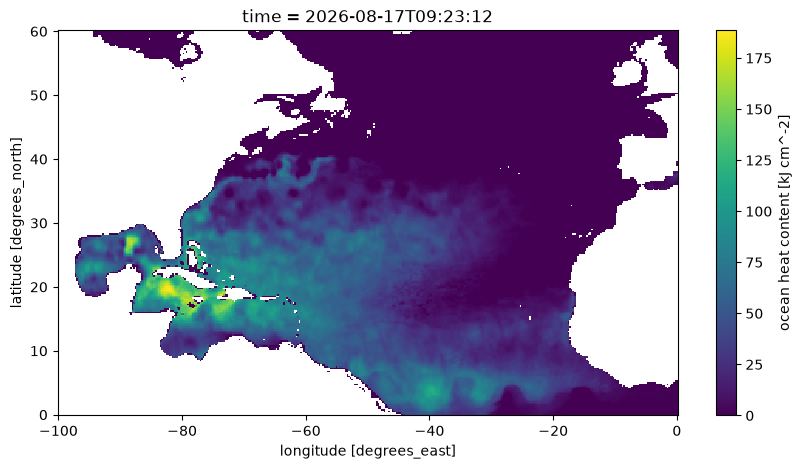

In [13]:
ds["ohc"].isel(time=0).plot(
    x="longitude",
    y="latitude",
    figsize=(10, 5),
)

## 9. A point time series

This should work logically, but remember the source `ohc` array is contiguous in each daily NetCDF. A single geographic point may therefore cause Icechunk/HDF virtual access to fetch the byte range for most or all of that day's `ohc` array. A physically rechunked archive would be much better for long point/glider time-series workloads.

In [14]:
# Pick a grid point by index for a tiny 3-day test.
point = ds["ohc"].isel(latitude=120, longitude=200).load()
point

<xarray.DataArray 'ohc' (time: 3)> Size: 12B
array([30.998844, 31.259792, 28.390844], dtype=float32)
Coordinates:
  * time       (time) datetime64[ns] 24B 2026-08-17T09:23:12 ... 2026-08-19T1...
    latitude   float32 4B 30.0
    longitude  float32 4B -50.0
Attributes:
    units:          kJ cm^-2
    long_name:      ocean heat content
    standard_name:  integral_of_sea_water_potential_temperature_wrt_depth_exp...
    grid_mapping:   crs
    valid_min:      0.0

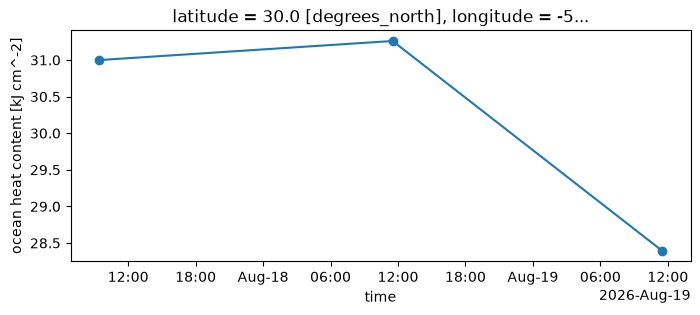

In [15]:
point.plot(marker="o", figsize=(8, 3))